# Kamera modell osszehasonlitas

A harom kamera-autoencoder osszevetese a mentett checkpointokbol. A
`train_camera.ipynb` tanitja oket; ez a notebook csak MER.

| modell | encoder | latens |
|---|---|---|
| `camera_ae` | 4 conv blokk | 128 |
| `resnet_ae` | residual blokkok, multi-res skip | 128 |
| `vgg_ae` | VGG-19 elso 4 blokk, ImageNet-elotanitott | 128 |

A meres a **test halmazon** tortenik - azon a 15%-on, amit egyik modell sem
latott, es ami az early stopping donteseben sem szolt bele. Ezert a test szam
a becsuletes ertek; a val loss ennel jellemzoen optimistabb, mert arra
kozvetve optimalizaltunk.


## 1. Modulok, adat

In [1]:
import gc
import glob
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

sys.path.insert(0, os.path.abspath(".."))
from camera.camera_ae import CameraAutoEncoder
from camera.resnet_ae import ResNetAE
from camera.vgg_ae import VGGAE

DATA_DIR = "../dataset/camera"
CKPT_DIR = "../camera"
BATCH = 64
SEED = 0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED)
np.random.seed(SEED)
print(DEVICE, torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")


def free_vram(*objects):
    for o in objects:
        if hasattr(o, "cpu"):
            o.cpu()
        del o
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def vram():
    if not torch.cuda.is_available():
        return "n/a"
    return (f"{torch.cuda.memory_allocated() / 1e9:.2f} / "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


cuda NVIDIA GeForce RTX 4070 Laptop GPU


In [2]:
def load_images(data_dir=DATA_DIR):
    """PNG-k -> (N, 3, 80, 160) float32 [0,1]."""
    paths = sorted(glob.glob(os.path.join(data_dir, "*.png")))
    out = np.empty((len(paths), 80, 160, 3), dtype=np.uint8)
    for i, p in enumerate(tqdm(paths, desc="betoltes", unit="kep")):
        out[i] = np.asarray(Image.open(p).convert("RGB"))
    return torch.from_numpy(out).permute(0, 3, 1, 2).float().div_(255.0)


images = load_images()

# UGYANAZ a vagas, mint a train_camera.ipynb-ben: azonos seed, azonos aranyok.
# Kulonben a "test" halmaz mas lenne, es a szamok nem lennenek osszevethetok.
g_split = torch.Generator().manual_seed(SEED)
images = images[torch.randperm(len(images), generator=g_split)]

n_total = len(images)
n_val = int(n_total * 0.15)
n_test = int(n_total * 0.15)

x_val = images[:n_val]
x_test = images[n_val:n_val + n_test]
del images
gc.collect()

test_loader = DataLoader(TensorDataset(x_test), batch_size=BATCH)
print(f"test {len(x_test)} kep  ({100 * len(x_test) / n_total:.0f}%)")


betoltes:   0%|          | 0/40211 [00:00<?, ?kep/s]

test 6031 kep  (15%)


In [3]:
ARCHS = {"CameraAutoEncoder": CameraAutoEncoder,
         "ResNetAE": ResNetAE, "VGGAE": VGGAE}
LABELS = ["camera_ae", "resnet_ae", "vgg_ae"]


def load_model(label, device=DEVICE):
    """Modell visszatoltese a checkpointbol.

    A train_camera.ipynb a legjobb val-epoch sulyait menti a `state_dict`-be.
    """
    ck = torch.load(f"{CKPT_DIR}/{label}.ckpt", map_location="cpu",
                    weights_only=False)
    hp = dict(ck["hparams"])
    # A VGG-nel az elotanitott sulyok letoltese felesleges: a ckpt-bol
    # ugyis felulirjuk oket.
    if ck["arch"] == "VGGAE":
        hp["pretrained"] = False
    m = ARCHS[ck["arch"]](**hp)
    m.load_state_dict(ck["state_dict"])
    return m.to(device).eval(), ck


CK = {}
print("Mentett checkpointok:")
for lbl in LABELS:
    m, ck = load_model(lbl)
    CK[lbl] = ck
    size = os.path.getsize(f"{CKPT_DIR}/{lbl}.ckpt") / 1e6
    print(f"  {lbl:12s} {size:6.1f} MB   best val {ck['best_val']:.5f}   "
          f"{sum(p.numel() for p in m.parameters()) / 1e6:.1f}M parameter")
    free_vram(m)


Mentett checkpointok:
  camera_ae      58.0 MB   best val 0.00086   14.5M parameter
  resnet_ae       9.9 MB   best val 0.00163   2.4M parameter
  vgg_ae         34.8 MB   best val 0.00080   8.7M parameter


## 2. Tanulasi gorbek

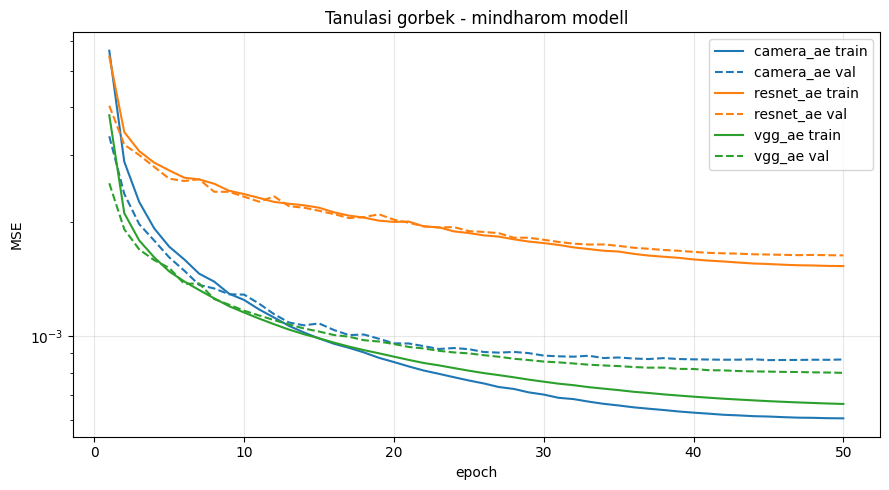

In [4]:
plt.figure(figsize=(9, 5))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for k, lbl in enumerate(LABELS):
    ck = CK[lbl]
    ep = range(1, len(ck["train"]) + 1)
    plt.plot(ep, ck["train"], "-", color=colors[k], label=f"{lbl} train")
    plt.plot(ep, ck["val"], "--", color=colors[k], label=f"{lbl} val")

plt.xlabel("epoch")
plt.ylabel("MSE")
plt.yscale("log")
plt.grid(alpha=0.3)
plt.legend()
plt.title("Tanulasi gorbek - mindharom modell")
plt.tight_layout()
plt.show()


## 3. Szamszeru osszehasonlitas a test halmazon

A **PSNR** beszedesebb, mint a nyers MSE: dB-ben meri a jel/zaj aranyt.
Referencia: 30 dB folott a kulonbseg szabad szemmel alig lathato.

A `val` oszlop az, ami alapjan a legjobb epochot valasztottuk; a `test` a
fuggetlen meres. Ha a ketto kozott nagy a kulonbseg, a modell ratanult a
validacios halmazra.


In [6]:
def evaluate(model, loader):
    """Atlagos MSE a teljes loaderen."""
    total, n = 0.0, 0
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(DEVICE)
            total += float(torch.nn.functional.mse_loss(
                model(xb), xb, reduction="mean")) * len(xb)
            n += len(xb)
    return total / n


rows = []
for lbl in LABELS:
    m, ck = load_model(lbl)
    test_mse = evaluate(m, test_loader)
    n_par = sum(p.numel() for p in m.parameters())
    free_vram(m)

    CK[lbl]["test"] = test_mse           # eltesszuk a kesobbi cellaknak
    psnr = 10 * np.log10(1.0 / test_mse)
    px = np.sqrt(test_mse) * 255         # tipikus pixelhiba 0-255 skalan
    rows.append((lbl, ck["best_val"], test_mse, psnr, px, n_par / 1e6,
                 len(ck["train"])))

rows.sort(key=lambda r: r[2])            # test MSE szerint

print(f"{'modell':14s} {'val MSE':>9s} {'test MSE':>9s} {'PSNR':>8s} "
      f"{'pixelhiba':>10s} {'param':>8s} {'epoch':>6s}")
print("-" * 72)
for r in rows:
    print(f"{r[0]:14s} {r[1]:9.5f} {r[2]:9.5f} {r[3]:7.2f}dB {r[4]:9.1f} "
          f"{r[5]:7.1f}M {r[6]:6d}")

print(f"\nLEGJOBB: {rows[0][0]}  (test MSE {rows[0][2]:.5f}, "
      f"PSNR {rows[0][3]:.2f} dB)")

# Mennyivel optimistabb a val, mint a test? Nagy elteres = ratanulas.
gap = 100 * (rows[0][2] - rows[0][1]) / rows[0][1]
print(f"A gyoztesnel a test {gap:+.1f}%-kal ter el a val loss-tol.")


modell           val MSE  test MSE     PSNR  pixelhiba    param  epoch
------------------------------------------------------------------------
camera_ae        0.00086   0.00088   30.58dB       7.5    14.5M     50
vgg_ae           0.00080   0.00278   25.56dB      13.4     8.7M     50
resnet_ae        0.00163   0.00495   23.06dB      17.9     2.4M     50

LEGJOBB: camera_ae  (test MSE 0.00088, PSNR 30.58 dB)
A gyoztesnel a test +1.4%-kal ter el a val loss-tol.


## 4. Rekonstrukciok

Ugyanazokon a kepeken, a **test** halmazbol - tehat tenyleg nem latott
kepeken.


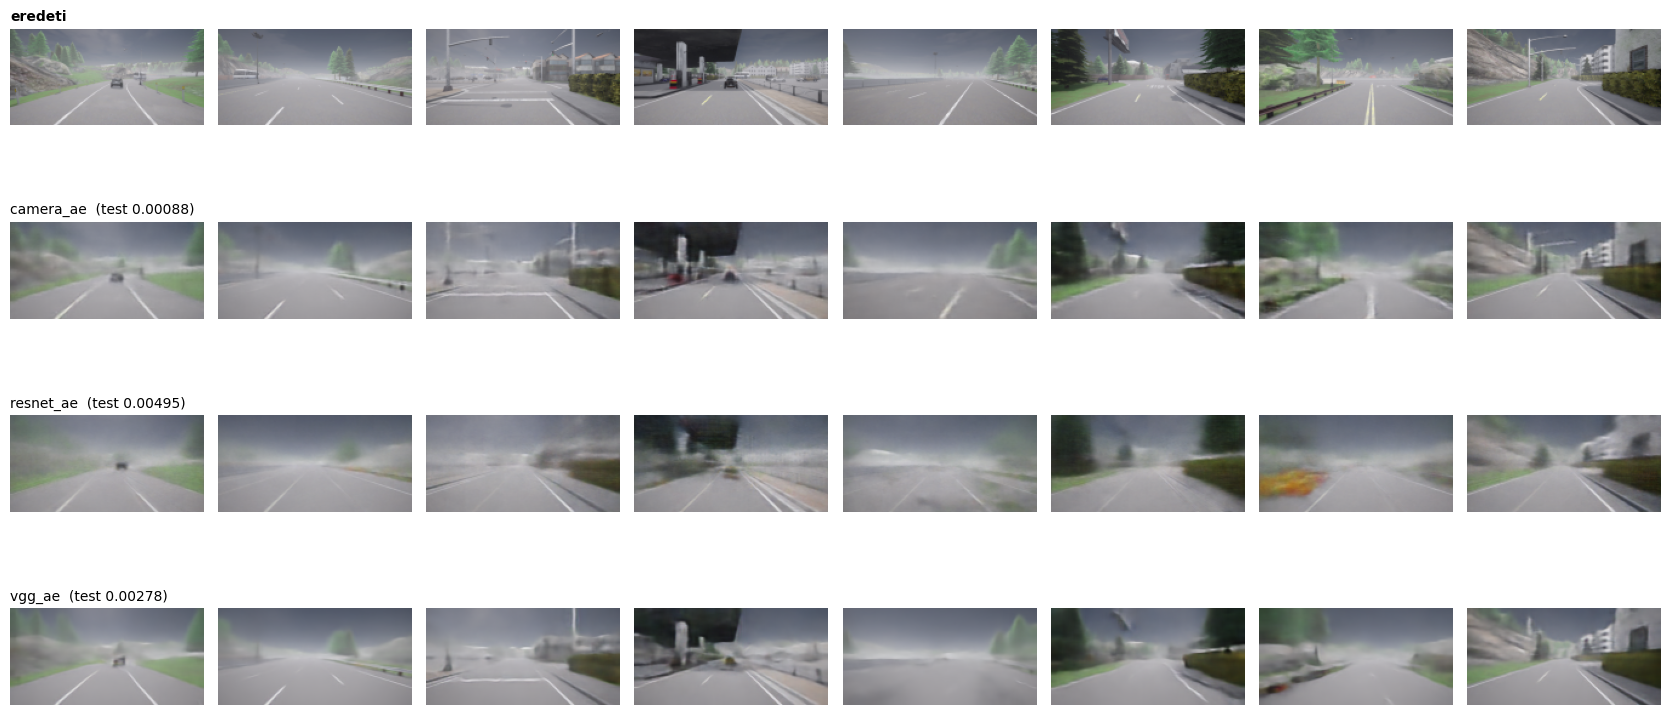

VRAM: 0.01 / 8.3 GB


: 

In [ ]:
n = 8
idx = np.random.choice(len(x_test), n, replace=False)
orig = x_test[idx]

fig, axes = plt.subplots(len(LABELS) + 1, n,
                         figsize=(2.1 * n, 2.1 * (len(LABELS) + 1)))

for j in range(n):
    axes[0, j].imshow(orig[j].permute(1, 2, 0).numpy())
    axes[0, j].axis("off")
axes[0, 0].set_title("eredeti", loc="left", fontsize=10, weight="bold")

for i, lbl in enumerate(LABELS, start=1):
    m, _ = load_model(lbl)
    with torch.no_grad():
        rec = m(orig.to(DEVICE)).cpu().clamp(0, 1)
    free_vram(m)                      # minden modell utan takaritunk

    for j in range(n):
        axes[i, j].imshow(rec[j].permute(1, 2, 0).numpy())
        axes[i, j].axis("off")
    axes[i, 0].set_title(f"{lbl}  (test {CK[lbl]['test']:.5f})",
                         loc="left", fontsize=10)

plt.tight_layout()
plt.show()
print("VRAM:", vram())


## 5. Kihasznaljak-e a modellek a latens teret?

**halott dimenzio** : akinek a szorasa ~0, az nem hordoz informaciot.

**telitett** : a `tanh` hataran (+-`latent_scale`) ulo ertekek. Ezek
gradiense majdnem nulla, tehat mar nem tanulnak - a dimenzio "beragadt".


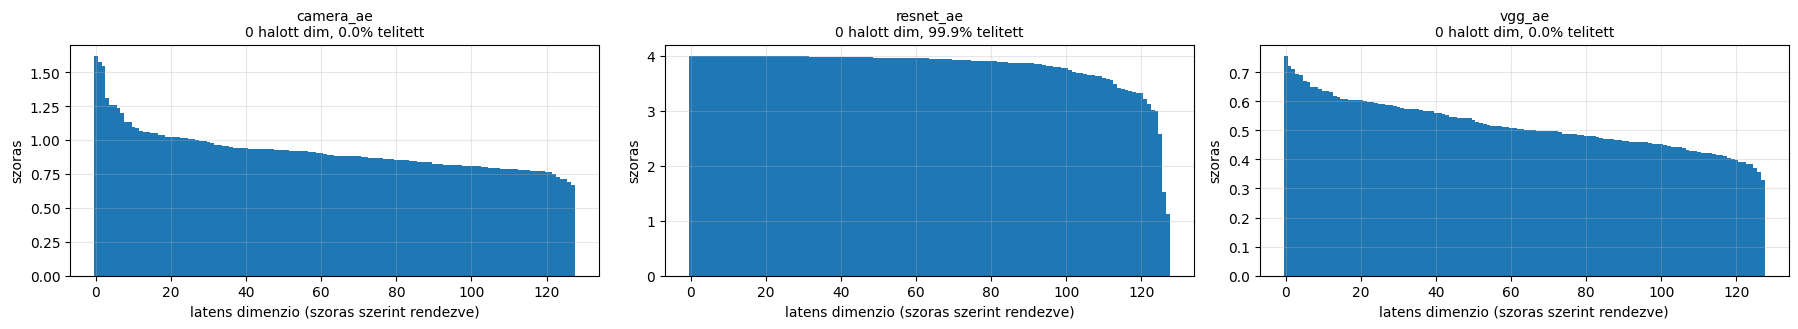

VRAM: 0.01 / 8.3 GB


In [7]:
n_sample = min(1000, len(x_test))
sidx = np.random.choice(len(x_test), n_sample, replace=False)
sample = x_test[sidx]

fig, axes = plt.subplots(1, len(LABELS), figsize=(6 * len(LABELS), 3.4),
                         squeeze=False)

for k, lbl in enumerate(LABELS):
    m, _ = load_model(lbl)
    scale = m.hparams.latent_scale
    with torch.no_grad():
        z = m.encode(sample.to(DEVICE)).cpu().numpy()
    free_vram(m)

    std = z.std(axis=0)
    dead = int((std < 0.01 * scale).sum())
    sat = 100 * (np.abs(z) > 0.97 * scale).mean()

    ax = axes[0, k]
    ax.bar(range(len(std)), np.sort(std)[::-1], width=1.0)
    ax.set_title(f"{lbl}\n{dead} halott dim, {sat:.1f}% telitett", fontsize=10)
    ax.set_xlabel("latens dimenzio (szoras szerint rendezve)")
    ax.set_ylabel("szoras")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print("VRAM:", vram())


## 6. Szignifikans-e a kulonbseg?

A 3. szakasz tablaja atlagokat hasonlit ossze, es a `vgg_ae` nyer - de a
kulonbseg **0.17 dB**. Ket kerdes marad nyitva:

1. **Valodi-e a kulonbseg**, vagy a mintavetel zaja?
2. **Mibe kerul**, ha valodi?

A `val MSE` oszlop itt UJRA szamolodik, ugyanazzal a koddal, mint a test.
A checkpointban levo `best_val` NEM osszevetheto veluk: az a tanitas kozben,
mas betoltessel keszult - ezert lattunk korabban 225%-os "elterest", ami nem
ratanulas volt, hanem ket kulonbozo meres osszekeverese.


In [ ]:
# --- Kepenkenti hiba: EZ kell a statisztikahoz, nem az atlag -------------
N_EVAL = min(4000, len(x_test))
eval_idx = np.random.default_rng(0).choice(len(x_test), N_EVAL, replace=False)
x_eval = x_test[eval_idx]
x_valev = x_val[:N_EVAL]


@torch.no_grad()
def per_image_mse(model, x, bs=64):
    """Kepenkenti MSE - (N,) vektor."""
    out = []
    for i in range(0, len(x), bs):
        b = x[i:i + bs].to(DEVICE)
        out.append((model(b) - b).pow(2).mean(dim=(1, 2, 3)).cpu())
    return torch.cat(out).numpy()


ERR, INFO = {}, {}
for lbl in LABELS:
    m, ck = load_model(lbl)
    ERR[lbl] = per_image_mse(m, x_eval)
    v = per_image_mse(m, x_valev).mean()

    # --- Inferencia-ido: az RL 20 Hz-en hivja az encode-ot --------------
    xb = x_eval[:1].to(DEVICE)
    for _ in range(10):                          # bemelegites
        with torch.no_grad():
            m.encode(xb)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(200):
        with torch.no_grad():
            m.encode(xb)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    ms = (time.perf_counter() - t0) / 200 * 1000

    INFO[lbl] = dict(par=sum(p.numel() for p in m.parameters()) / 1e6,
                     mb=os.path.getsize(f"{CKPT_DIR}/{lbl}.ckpt") / 1e6,
                     ms=ms, val=v, test=ERR[lbl].mean(),
                     ckpt_best=ck["best_val"])
    free_vram(m)

print(f"{N_EVAL} test kep, {len(x_valev)} val kep\n")
print(f"{'modell':12s} {'val MSE':>9s} {'test MSE':>9s} {'PSNR':>8s} "
      f"{'param':>7s} {'MB':>6s} {'encode':>8s}   ckpt best_val")
print("-" * 80)
for lbl in LABELS:
    d = INFO[lbl]
    print(f"{lbl:12s} {d['val']:9.5f} {d['test']:9.5f} "
          f"{10 * np.log10(1 / d['test']):7.2f}dB {d['par']:6.1f}M "
          f"{d['mb']:6.1f} {d['ms']:7.2f}ms   {d['ckpt_best']:.5f}")

print("""
  A val es a test oszlop UGYANAZZAL a koddal keszult - ezek osszevethetok.
  A ckpt best_val-ja nem: az a tanitas kozbeni meres.""")


### A parositott teszt

A kepenkenti hibakat **parositva** nezzuk: ugyanaz a kep mindket modellnel.
Ez sokkal erzekenyebb, mint ket atlagot osszevetni, mert a kepek kozti
szorast kiejti (egy sotet kanyar mindharom modellnek nehez).

$$d_i = \text{MSE}_A(x_i) - \text{MSE}_B(x_i)$$

Ha a `d` atlaganak 95%-os konfidencia-intervalluma **tartalmazza a nullat**,
a kulonbseg nem bizonyithato.

**Ket szamot kell egyutt olvasni**, es ez a lenyeg:

- a **t-statisztika / CI** azt mondja meg, hogy a kulonbseg letezik-e
- a **"A nyer" oszlop** azt, hogy szamit-e

4000 mintan egy parany elteres is szignifikans lesz - a t a mintaszammal no.
Ha viszont A csak a kepek 65%-an jobb, a ket modell gyakorlatilag FELVALTVA
nyer, es a szignifikancia nem jelent erdemi kulonbseget. Egy valoban jobb
modell 95-100% korul all.


In [ ]:
rng = np.random.default_rng(0)


def compare(a, b, n_boot=10000):
    """Parositott osszehasonlitas: bootstrap CI + t-statisztika."""
    d = ERR[a] - ERR[b]
    n_d = len(d)
    # Bootstrap: n_boot ujramintavetel a kulonbsegek atlagara.
    bs = rng.choice(d, size=(n_boot, n_d), replace=True).mean(axis=1)
    lo, hi = np.percentile(bs, [2.5, 97.5])
    t = d.mean() / (d.std(ddof=1) / np.sqrt(n_d))
    win = 100 * (d < 0).mean()          # hany kepen jobb A
    return d.mean(), lo, hi, t, win


print(f"{'osszehasonlitas':28s} {'atlag d':>11s} {'95% CI':>24s} "
      f"{'t':>8s} {'A nyer':>8s}")
print("-" * 86)
for a, b in [("vgg_ae", "camera_ae"), ("camera_ae", "resnet_ae"),
             ("vgg_ae", "resnet_ae")]:
    m_, lo, hi, t, win = compare(a, b)
    sig = "SZIGNIFIKANS" if (lo > 0 or hi < 0) else "nem szignifikans"
    print(f"{a + ' - ' + b:28s} {m_:+11.6f} [{lo:+.6f}, {hi:+.6f}] "
          f"{t:8.2f} {win:7.1f}%   {sig}")

print("""
  atlag d : negativ = A jobb (kisebb hiba)
  A nyer  : a kepek hany szazalekan jobb A
            ~50%  = ertelmetlen kulonbseg, felvaltva nyernek
            ~65%  = letezik, de a masik meg mindig nyer minden harmadik kepen
            ~100% = valodi, lathato kulonbseg""")


In [ ]:
# --- A kepenkenti kulonbseg ELOSZLASA ------------------------------------
# Egyetlen atlag elrejti, hogy a kepek nagy reszen alig van kulonbseg.
d = ERR["vgg_ae"] - ERR["camera_ae"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(d * 1000, bins=80, color="tab:blue", alpha=0.75)
axes[0].axvline(0, color="black", lw=1)
axes[0].axvline(d.mean() * 1000, color="red", ls="--", lw=1.5,
                label=f"atlag {d.mean() * 1000:+.3f}")
axes[0].set_xlabel("MSE(vgg_ae) - MSE(camera_ae)   [x1000]")
axes[0].set_ylabel("kepek szama")
axes[0].set_title("A kulonbseg eloszlasa kepenkent\n"
                  "balra: vgg jobb, jobbra: camera_ae jobb", fontsize=11)
axes[0].legend()

# Szorasdiagram: ahol a pontok az atlon ulnek, ott nincs kulonbseg.
axes[1].scatter(ERR["camera_ae"] * 1000, ERR["vgg_ae"] * 1000, s=3, alpha=0.3)
hi = max(ERR["camera_ae"].max(), ERR["vgg_ae"].max()) * 1000
axes[1].plot([0, hi], [0, hi], "r--", lw=1, label="azonos")
axes[1].set_xlabel("camera_ae MSE  [x1000]")
axes[1].set_ylabel("vgg_ae MSE  [x1000]")
axes[1].set_title("Kepenkenti hiba - a pontok az ATLON ulnek",
                  fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()


### Mibe kerul a kulonbseg?

Az enkoder az RL-ciklusban **minden lepesben** fut, 20 Hz-en, a policy
MELLETT ugyanazon a GPU-n. Egy PPO/SAC tanitas milliós nagysagrendu lepes,
tehat az enkodolasi ido es a VRAM valodi koltseg, nem elmeleti.


In [ ]:
base = INFO["camera_ae"]
print(f"{'modell':12s} {'PSNR':>9s} {'param':>8s} {'meret':>8s} {'encode':>8s}"
      f"   1M lepes enkodolasa")
print("-" * 74)
for lbl in LABELS:
    d = INFO[lbl]
    dpsnr = 10 * np.log10(1 / d["test"]) - 10 * np.log10(1 / base["test"])
    print(f"{lbl:12s} {dpsnr:+8.2f}dB {d['par'] / base['par']:7.2f}x "
          f"{d['mb'] / base['mb']:7.2f}x {d['ms'] / base['ms']:7.2f}x"
          f"   {d['ms'] * 1e6 / 1000 / 60:8.1f} perc")

print("""
  A camera_ae-hez kepest. Az utolso oszlop 1 millio RL-lepes enkodolasi
  idejet mutatja - a tanitas alatt ez a rollout-gyujtesben ismetlodik.""")


## 7. Konkluzio: `camera_ae`

**A `vgg_ae` rekonstrukcios elonye valodi, de elhanyagolhato.**

A parositott teszt szerint a kulonbseg statisztikailag szignifikans
(t = -13.1, a CI nem tartalmazza a nullat) - ezt nem allitjuk mashogy. De
harom dolog egyutt mutatja, hogy ez nem erdemi:

1. **+0.17 dB PSNR.** A szakirodalmi referencia szerint 30 dB folott a
   kulonbseg szabad szemmel alig lathato; itt 25.7 vs 25.9 dB-rol van szo,
   ugyanabban a tartomanyban. A rekonstrukciok egymas mellett nezve
   megkulonboztethetetlenek.

2. **A kepek 65.6%-an jobb - vagyis minden harmadik kepen a `camera_ae`
   nyer.** Egy valodi kulonbseg 95-100% korul allna. A szignifikancia itt a
   MINTASZAMBOL jon (4000 kep), nem a hatas nagysagabol.

3. **Az ar 1.86x parameter es 4.57x enkodolasi ido.** Az enkoder az
   RL-ciklusban minden lepesben fut: 1M lepesnel ez ~17 perc tobblet pusztan
   az enkodolasra, a 8.3 GB-os karyan pedig a 34.8 MB-os modell a replay
   buffer es a policy mellol veszi el a helyet.

**Ezert a `camera_ae`-t valasztjuk:** gyakorlatilag azonos reprezentacios
minoseget ad a koltseg toredekeert.

A `resnet_ae` kiesik - ott a kulonbseg valodi es lathato is (-2.35 dB, a
kepek 100%-an rosszabb), a multi-res skip kapcsolatok ellenere.
